# Fund Performance Analytics

This notebook evaluates the historical performance of mutual fund schemes using return-based metrics such as Daily Returns, CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, Maximum Drawdown, and a composite Fund Scorecard. The analysis also compares top-performing funds with benchmark indices.

In [4]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns
import plotly.express as px 
import plotly.graph_objects as go 
from scipy.stats import linregress
plt.style.use("ggplot")

In [5]:
# Load cleaned datasets

nav = pd.read_csv("../data/processed/02_nav_history_clean.csv")
fund = pd.read_csv("../data/processed/01_fund_master_clean.csv")
benchmark = pd.read_csv("../data/processed/10_benchmark_indices_clean.csv")

# Convert dates
nav["date"] = pd.to_datetime(nav["date"])
benchmark["date"] = pd.to_datetime(benchmark["date"])

print("NAV Shape :", nav.shape)
print("Fund Shape:", fund.shape)
print("Benchmark Shape:", benchmark.shape)

NAV Shape : (46000, 3)
Fund Shape: (40, 15)
Benchmark Shape: (8050, 3)


In [6]:
nav = nav.merge(
    fund[["amfi_code", "scheme_name", "expense_ratio_pct"]],
    on="amfi_code",
    how="left"
)

nav.head()

,amfi_code,date,nav,scheme_name,expense_ratio_pct
0,100016,2022-01-03,520.4608,HDFC Top 100 Fund - Regular Plan - Growth,1.55
1,100016,2022-01-04,515.0971,HDFC Top 100 Fund - Regular Plan - Growth,1.55
2,100016,2022-01-05,521.7239,HDFC Top 100 Fund - Regular Plan - Growth,1.55
3,100016,2022-01-06,515.7880,HDFC Top 100 Fund - Regular Plan - Growth,1.55
4,100016,2022-01-07,515.1639,HDFC Top 100 Fund - Regular Plan - Growth,1.55


# Daily Return Analysis

This section computes daily returns for all mutual fund schemes using historical NAV values.

Formula:

Daily Return = (Today's NAV / Previous Day's NAV) - 1

These returns form the basis for CAGR, Sharpe Ratio, Sortino Ratio, Alpha, Beta, and Maximum Drawdown calculations.

In [7]:
# Sort values
nav = nav.sort_values(["scheme_name", "date"])

# Daily Return
nav["daily_return"] = (
    nav.groupby("scheme_name")["nav"]
       .pct_change()
)

nav.head()

,amfi_code,date,nav,scheme_name,expense_ratio_pct,daily_return
3450,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,1.6,NaN
3451,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,1.6,0.001153
3452,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,1.6,0.003866
3453,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,1.6,-0.002128
3454,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,1.6,-0.006314


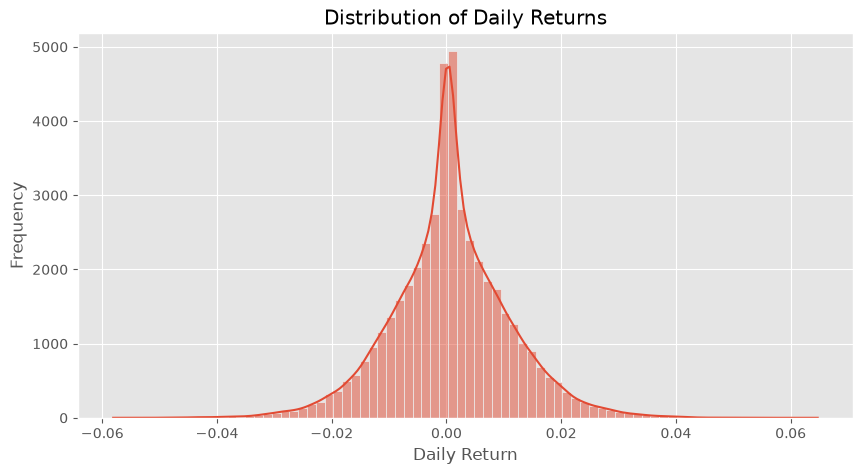

In [8]:
plt.figure(figsize=(10,5))

sns.histplot(
    nav["daily_return"].dropna(),
    bins=80,
    kde=True
)

plt.title("Distribution of Daily Returns")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")

plt.show()

# CAGR Analysis

Compound Annual Growth Rate (CAGR) measures the annualized growth of a mutual fund over a fixed investment period.

Formula:

CAGR = (Ending NAV / Beginning NAV)^(1/n) - 1

where n is the number of years.

This analysis computes:
- 1-Year CAGR
- 3-Year CAGR
- 5-Year CAGR

for all available mutual fund schemes.

In [9]:
latest_date = nav["date"].max()

latest_nav = (
    nav[nav["date"] == latest_date]
    [["amfi_code", "nav"]]
    .rename(columns={"nav": "latest_nav"})
)

latest_nav.head()

,amfi_code,latest_nav
4599,101206,773.2939
6899,101208,410.1021
5749,101207,53.9836
18399,119093,58.4203
17249,119092,50.8387


In [10]:
def calculate_cagr(df, years):
    
    end_date = df["date"].max()
    start_date = end_date - pd.DateOffset(years=years)

    start_nav = (
        df[df["date"] >= start_date]
        .groupby("amfi_code")
        .first()["nav"]
    )

    end_nav = (
        df.groupby("amfi_code")
        .last()["nav"]
    )

    cagr = ((end_nav / start_nav) ** (1 / years) - 1) * 100

    return cagr

In [11]:
cagr_1 = calculate_cagr(nav, 1)
cagr_3 = calculate_cagr(nav, 3)
cagr_5 = calculate_cagr(nav, 5)

In [12]:
cagr_table = pd.DataFrame({
    "1Y CAGR (%)": cagr_1,
    "3Y CAGR (%)": cagr_3,
    "5Y CAGR (%)": cagr_5
}).reset_index()

In [13]:
cagr_table = cagr_table.merge(
    fund[["amfi_code", "scheme_name"]],
    on="amfi_code",
    how="left"
)

cagr_table = cagr_table[
    ["scheme_name", "1Y CAGR (%)", "3Y CAGR (%)", "5Y CAGR (%)"]
]

cagr_table.head()

,scheme_name,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
0,HDFC Top 100 Fund - Regular Plan - Growth,-2.224271,1.292649,2.316843
1,HDFC Short Term Debt Fund - Regular - Growth,3.704969,3.916390,3.912653
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
3,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730
4,ABSL Small Cap Fund - Regular - Growth,-23.986032,-4.152381,6.953336


In [14]:
cagr_table = cagr_table.sort_values(
    "5Y CAGR (%)",
    ascending=False
)

cagr_table.head(10)

,scheme_name,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%)
25,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762
21,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224
39,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430
36,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860
34,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277
30,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494
2,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068
38,DSP Midcap Fund - Regular - Growth,21.481222,26.869991,25.611807
16,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309
19,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873


C:\Users\yadav\AppData\Local\Temp\ipykernel_21932\3870475755.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


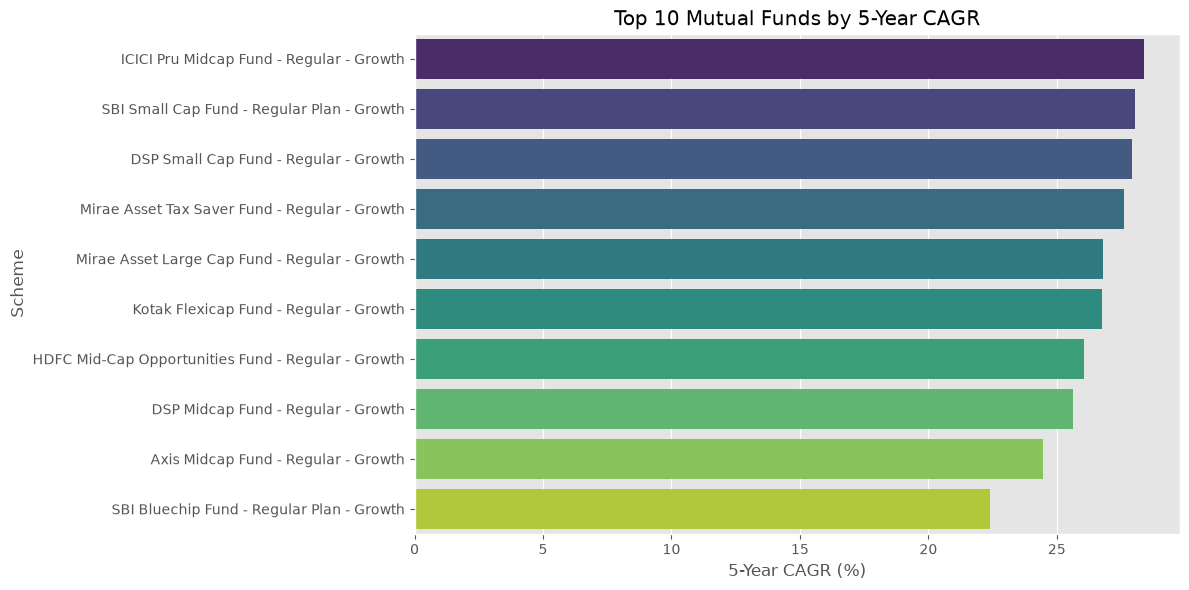

In [15]:
top10 = cagr_table.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="5Y CAGR (%)",
    y="scheme_name",
    palette="viridis"
)

plt.title("Top 10 Mutual Funds by 5-Year CAGR")
plt.xlabel("5-Year CAGR (%)")
plt.ylabel("Scheme")

plt.tight_layout()
plt.show()

# Sharpe Ratio Analysis

The Sharpe Ratio measures the risk-adjusted return of a mutual fund.

Formula:

Sharpe Ratio = (Rp − Rf) / σ × √252

Where:
- Rp = Average Daily Return
- Rf = Risk-Free Rate (6.5% RBI Repo Rate Proxy)
- σ = Standard Deviation of Daily Returns

Higher Sharpe Ratios indicate better returns per unit of risk.

In [16]:
# Annual risk-free rate
risk_free_rate = 0.065

# Convert annual rate to daily
daily_rf = risk_free_rate / 252

In [17]:
sharpe = (
    nav.groupby("scheme_name")["daily_return"]
    .agg(["mean", "std"])
    .reset_index()
)

sharpe["Sharpe Ratio"] = (
    (sharpe["mean"] - daily_rf)
    / sharpe["std"]
) * np.sqrt(252)

In [18]:
sharpe = sharpe.sort_values(
    "Sharpe Ratio",
    ascending=False
)

sharpe.reset_index(drop=True, inplace=True)

sharpe.head(10)

,scheme_name,mean,std,Sharpe Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,0.001074,0.008941,1.448291
1,Kotak Flexicap Fund - Regular - Growth,0.001082,0.010008,1.306744
2,Mirae Asset Tax Saver Fund - Regular - Growth,0.001124,0.011134,1.234930
3,SBI Bluechip Fund - Regular Plan - Growth,0.000917,0.008656,1.208267
4,ICICI Pru Midcap Fund - Regular - Growth,0.001161,0.012152,1.180101
5,DSP Midcap Fund - Regular - Growth,0.001055,0.011179,1.132122
6,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.001080,0.011929,1.093699
7,Nippon India Large Cap Fund - Regular - Growth,0.000865,0.008913,1.081659
8,ABSL Frontline Equity Fund - Regular - Growth,0.000852,0.009177,1.027213
9,ICICI Pru Bluechip Fund - Direct - Growth,0.000843,0.009048,1.026524


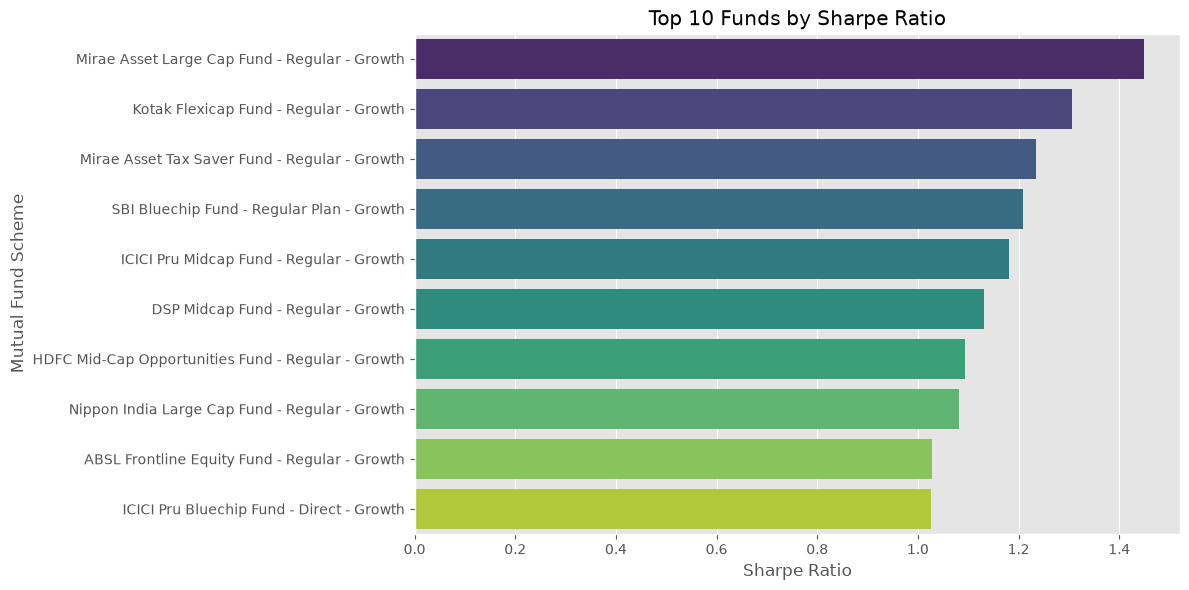

In [19]:
top10 = sharpe.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Sharpe Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Funds by Sharpe Ratio")
plt.xlabel("Sharpe Ratio")
plt.ylabel("Mutual Fund Scheme")

plt.tight_layout()
plt.show()

# Sortino Ratio Analysis

The Sortino Ratio measures the risk-adjusted return of a mutual fund by considering only downside risk.

Formula:

Sortino Ratio = (Rp − Rf) / Downside Deviation × √252

Only negative daily returns are used to calculate downside deviation.

A higher Sortino Ratio indicates better downside risk-adjusted performance.

In [20]:
sortino_list = []

for scheme, group in nav.groupby("scheme_name"):

    avg_return = group["daily_return"].mean()

    downside_returns = group.loc[
        group["daily_return"] < 0,
        "daily_return"
    ]

    downside_std = downside_returns.std()

    if downside_std == 0 or np.isnan(downside_std):
        sortino = np.nan
    else:
        sortino = (
            (avg_return - daily_rf)
            / downside_std
        ) * np.sqrt(252)

    sortino_list.append({
        "scheme_name": scheme,
        "Sortino Ratio": sortino
    })

In [21]:
sortino = pd.DataFrame(sortino_list)

sortino = sortino.sort_values(
    "Sortino Ratio",
    ascending=False
)

sortino.reset_index(drop=True, inplace=True)

sortino.head(10)

,scheme_name,Sortino Ratio
0,Mirae Asset Large Cap Fund - Regular - Growth,2.385644
1,Kotak Flexicap Fund - Regular - Growth,2.364320
2,Mirae Asset Tax Saver Fund - Regular - Growth,2.146914
3,SBI Bluechip Fund - Regular Plan - Growth,2.140267
4,ICICI Pru Midcap Fund - Regular - Growth,2.029353
5,DSP Midcap Fund - Regular - Growth,1.875101
6,Nippon India Large Cap Fund - Regular - Growth,1.850133
7,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,1.829134
8,ICICI Pru Bluechip Fund - Direct - Growth,1.805294
9,ABSL Frontline Equity Fund - Regular - Growth,1.799563


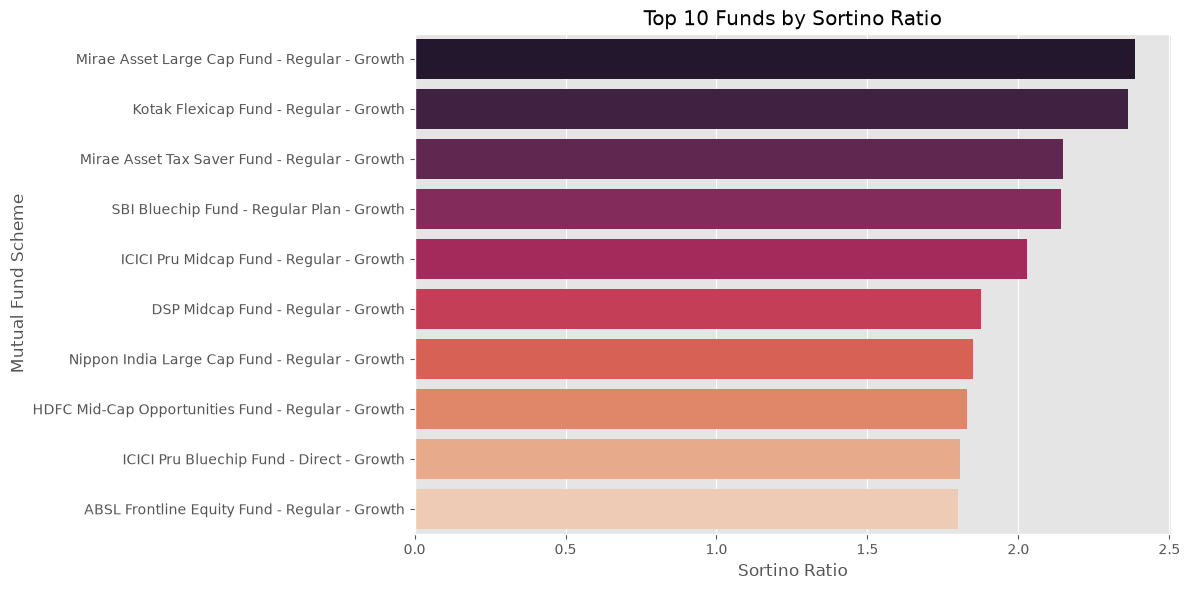

In [22]:
top10 = sortino.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Sortino Ratio",
    y="scheme_name",
    hue="scheme_name",
    palette="rocket",
    legend=False
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("Sortino Ratio")
plt.ylabel("Mutual Fund Scheme")

plt.tight_layout()

plt.show()

In [23]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

benchmark = benchmark.sort_values(
    ["index_name", "date"]
)

benchmark["benchmark_return"] = (
    benchmark.groupby("index_name")["close_value"]
    .pct_change()
)

In [24]:
nifty100 = benchmark[
    benchmark["index_name"] == "NIFTY100"
].copy()

nifty100.head()

,date,index_name,close_value,benchmark_return
1150,2022-01-03,NIFTY100,17778.24,NaN
1151,2022-01-04,NIFTY100,17537.52,-0.013540
1152,2022-01-05,NIFTY100,17607.73,0.004003
1153,2022-01-06,NIFTY100,17556.05,-0.002935
1154,2022-01-07,NIFTY100,17664.02,0.006150


In [25]:
merged = nav.merge(
    nifty100[["date", "benchmark_return"]],
    on="date",
    how="inner"
)

merged.head()

,amfi_code,date,nav,scheme_name,expense_ratio_pct,daily_return,benchmark_return
0,101206,2022-01-03,305.0996,ABSL Frontline Equity Fund - Regular - Growth,1.6,NaN,NaN
1,101206,2022-01-04,305.4514,ABSL Frontline Equity Fund - Regular - Growth,1.6,0.001153,-0.013540
2,101206,2022-01-05,306.6324,ABSL Frontline Equity Fund - Regular - Growth,1.6,0.003866,0.004003
3,101206,2022-01-06,305.9800,ABSL Frontline Equity Fund - Regular - Growth,1.6,-0.002128,-0.002935
4,101206,2022-01-07,304.0480,ABSL Frontline Equity Fund - Regular - Growth,1.6,-0.006314,0.006150


In [26]:
alpha_beta = []

for scheme, group in merged.groupby("scheme_name"):

    df = group.dropna(subset=["daily_return", "benchmark_return"])

    if len(df) < 30:
        continue

    beta, intercept, r_value, p_value, std_err = linregress(
        df["benchmark_return"],
        df["daily_return"]
    )

    alpha_beta.append({
        "scheme_name": scheme,
        "Alpha (%)": intercept * 252 * 100,
        "Beta": beta,
        "R_squared": r_value**2
    })

alpha_beta = pd.DataFrame(alpha_beta)

alpha_beta.head()

,scheme_name,Alpha (%),Beta,R_squared
0,ABSL Frontline Equity Fund - Regular - Growth,21.399785,0.021086,0.000348
1,ABSL Liquid Fund - Regular - Growth,6.086146,0.000267,0.000046
2,ABSL Small Cap Fund - Regular - Growth,10.897092,-0.065289,0.001064
3,Axis Bluechip Fund - Direct - Growth,8.232801,0.025883,0.000569
4,Axis Bluechip Fund - Regular - Growth,6.899530,0.009731,0.000081


# Maximum Drawdown Analysis

Maximum Drawdown (MDD) measures the largest decline from a fund's historical peak NAV before recovering.

Formula:

Maximum Drawdown = (NAV / Running Maximum NAV) - 1

A smaller drawdown indicates better downside protection during market declines.

In [27]:
# Ensure data is sorted
nav = nav.sort_values(["scheme_name", "date"])

# Running maximum NAV
nav["running_max"] = (
    nav.groupby("scheme_name")["nav"]
    .cummax()
)

# Drawdown
nav["drawdown"] = (
    nav["nav"] / nav["running_max"]
) - 1

In [28]:
max_drawdown = (
    nav.groupby("scheme_name")["drawdown"]
    .min()
    .reset_index()
)

max_drawdown.rename(
    columns={"drawdown": "Maximum Drawdown"},
    inplace=True
)

max_drawdown.head()

,scheme_name,Maximum Drawdown
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916
1,ABSL Liquid Fund - Regular - Growth,-0.001622
2,ABSL Small Cap Fund - Regular - Growth,-0.354469
3,Axis Bluechip Fund - Direct - Growth,-0.217514
4,Axis Bluechip Fund - Regular - Growth,-0.144016


In [29]:
worst_dates = (
    nav.loc[
        nav.groupby("scheme_name")["drawdown"].idxmin(),
        ["scheme_name", "date", "drawdown"]
    ]
)

worst_dates.head()

,scheme_name,date,drawdown
3842,ABSL Frontline Equity Fund - Regular - Growth,2023-07-05,-0.112916
6191,ABSL Liquid Fund - Regular - Growth,2023-09-12,-0.001622
5735,ABSL Small Cap Fund - Regular - Growth,2026-05-11,-0.354469
17610,Axis Bluechip Fund - Direct - Growth,2023-05-22,-0.217514
16909,Axis Bluechip Fund - Regular - Growth,2025-02-07,-0.144016


In [30]:
max_drawdown = max_drawdown.merge(
    worst_dates[["scheme_name", "date"]],
    on="scheme_name"
)

max_drawdown.rename(
    columns={"date": "Worst Drawdown Date"},
    inplace=True
)

max_drawdown.head()

,scheme_name,Maximum Drawdown,Worst Drawdown Date
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
1,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-12
2,ABSL Small Cap Fund - Regular - Growth,-0.354469,2026-05-11
3,Axis Bluechip Fund - Direct - Growth,-0.217514,2023-05-22
4,Axis Bluechip Fund - Regular - Growth,-0.144016,2025-02-07


In [31]:
max_drawdown = max_drawdown.sort_values(
    "Maximum Drawdown",
    ascending=False
)

max_drawdown.head(10)

,scheme_name,Maximum Drawdown,Worst Drawdown Date
17,ICICI Pru Liquid Fund - Regular - Growth,-0.000977,2025-10-20
23,Kotak Liquid Fund - Regular - Growth,-0.001163,2024-04-30
1,ABSL Liquid Fund - Regular - Growth,-0.001622,2023-09-12
12,HDFC Short Term Debt Fund - Regular - Growth,-0.043083,2023-07-28
34,SBI Magnum Gilt Fund - Regular Plan - Growth,-0.043287,2025-04-01
28,Nippon India Gilt Securities Fund - Regular - ...,-0.083164,2024-02-09
39,UTI Nifty 50 Index Fund - Regular - Growth,-0.108599,2022-03-29
25,Mirae Asset Large Cap Fund - Regular - Growth,-0.112657,2023-10-20
0,ABSL Frontline Equity Fund - Regular - Growth,-0.112916,2023-07-05
27,Nippon India ETF Nifty 50 BeES,-0.116506,2022-06-09


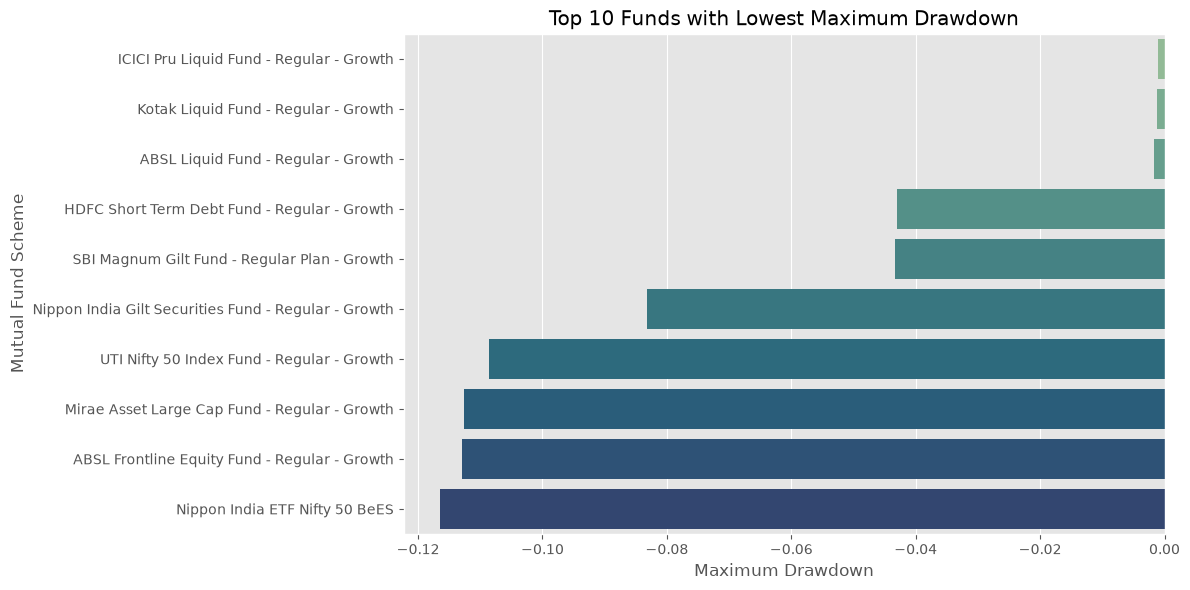

In [32]:
top10 = max_drawdown.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Maximum Drawdown",
    y="scheme_name",
    hue="scheme_name",
    palette="crest",
    legend=False
)

plt.title("Top 10 Funds with Lowest Maximum Drawdown")

plt.xlabel("Maximum Drawdown")
plt.ylabel("Mutual Fund Scheme")

plt.tight_layout()

plt.show()

# Fund Scorecard

The Fund Scorecard combines multiple performance metrics into a single score out of 100.

Scoring Weights:

- 30% → 3-Year CAGR Rank
- 25% → Sharpe Ratio Rank
- 20% → Alpha Rank
- 15% → Expense Ratio Rank (Lower Expense = Better)
- 10% → Maximum Drawdown Rank (Smaller Drawdown = Better)

Funds are ranked based on their weighted composite score.

In [33]:
scorecard = cagr_table.merge(
    sharpe[["scheme_name", "Sharpe Ratio"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    alpha_beta[["scheme_name", "Alpha (%)"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    max_drawdown[["scheme_name", "Maximum Drawdown"]],
    on="scheme_name"
)

scorecard = scorecard.merge(
    fund[["scheme_name", "expense_ratio_pct"]],
    on="scheme_name"
)

scorecard.head()

,scheme_name,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%),Sharpe Ratio,Alpha (%),Maximum Drawdown,expense_ratio_pct
0,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762,1.180101,29.263583,-0.181885,1.36
1,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224,0.945308,30.336965,-0.287060,1.43
2,DSP Small Cap Fund - Regular - Growth,65.138719,27.000427,27.917430,0.949796,30.057878,-0.311719,1.52
3,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860,1.234930,28.270368,-0.163967,1.60
4,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277,1.448291,26.983751,-0.112657,1.46


In [34]:
scorecard["CAGR Rank"] = scorecard["3Y CAGR (%)"].rank(ascending=False)

scorecard["Sharpe Rank"] = scorecard["Sharpe Ratio"].rank(ascending=False)

scorecard["Alpha Rank"] = scorecard["Alpha (%)"].rank(ascending=False)

scorecard["Expense Rank"] = scorecard["expense_ratio_pct"].rank(ascending=True)

scorecard["Drawdown Rank"] = scorecard["Maximum Drawdown"].rank(ascending=False)

In [35]:
scorecard["Score"] = (

    (41 - scorecard["CAGR Rank"]) * 0.30 +

    (41 - scorecard["Sharpe Rank"]) * 0.25 +

    (41 - scorecard["Alpha Rank"]) * 0.20 +

    (41 - scorecard["Expense Rank"]) * 0.15 +

    (41 - scorecard["Drawdown Rank"]) * 0.10

)

In [36]:
scorecard = scorecard.sort_values(
    "Score",
    ascending=False
)

scorecard.reset_index(drop=True, inplace=True)

scorecard.head(10)

,scheme_name,1Y CAGR (%),3Y CAGR (%),5Y CAGR (%),Sharpe Ratio,Alpha (%),Maximum Drawdown,expense_ratio_pct,CAGR Rank,Sharpe Rank,Alpha Rank,Expense Rank,Drawdown Rank,Score
0,Mirae Asset Large Cap Fund - Regular - Growth,20.360678,34.000916,26.799277,1.448291,26.983751,-0.112657,1.46,2.0,1.0,7.0,23.0,8.0,34.500
1,ICICI Pru Midcap Fund - Regular - Growth,29.604659,31.777537,28.376762,1.180101,29.263583,-0.181885,1.36,5.0,5.0,3.0,15.0,25.0,32.900
2,Kotak Flexicap Fund - Regular - Growth,26.657082,29.582770,26.742494,1.306744,27.330465,-0.129740,1.45,7.0,2.0,5.0,22.0,13.0,32.800
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,53.232396,32.442459,26.074068,1.093699,27.195355,-0.162172,1.38,4.0,7.0,6.0,17.0,20.0,32.300
4,ICICI Pru Bluechip Fund - Direct - Growth,13.064279,32.487429,20.234028,1.026524,21.194827,-0.125883,0.80,3.0,10.0,13.0,12.0,12.0,32.000
5,Axis Midcap Fund - Regular - Growth,22.261065,35.111802,24.445309,0.998231,26.076669,-0.209609,1.38,1.0,11.0,9.0,17.0,28.0,30.800
6,SBI Bluechip Fund - Regular Plan - Growth,60.437341,30.456524,22.384873,1.208267,23.201007,-0.150124,1.54,6.0,4.0,10.0,30.5,17.0,29.925
7,Mirae Asset Tax Saver Fund - Regular - Growth,39.751761,29.178902,27.629860,1.234930,28.270368,-0.163967,1.60,8.0,3.0,4.0,36.5,21.0,29.475
8,ABSL Frontline Equity Fund - Regular - Growth,47.924120,28.967695,20.442730,1.027213,21.399785,-0.112916,1.60,9.0,9.0,12.0,36.5,9.0,27.275
9,SBI Small Cap Fund - Regular Plan - Growth,82.776059,26.669922,28.033224,0.945308,30.336965,-0.287060,1.43,12.0,14.0,1.0,21.0,36.0,26.950


In [37]:
scorecard.to_csv(
    "../data/processed/fund_scorecard.csv",
    index=False
)

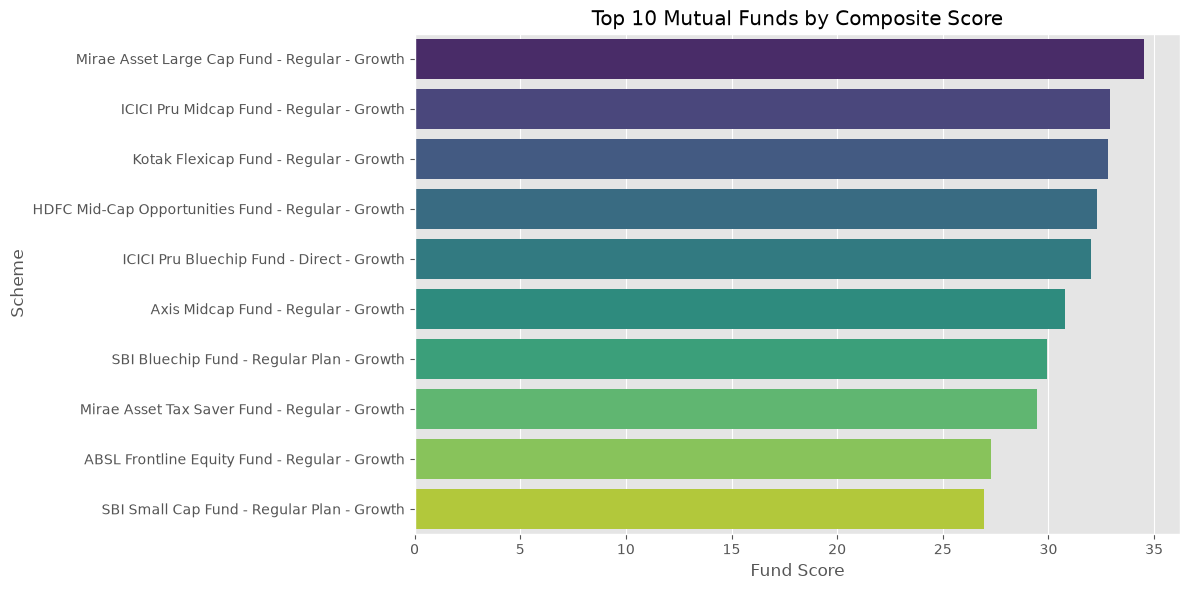

In [38]:
top10 = scorecard.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top10,
    x="Score",
    y="scheme_name",
    hue="scheme_name",
    palette="viridis",
    legend=False
)

plt.title("Top 10 Mutual Funds by Composite Score")

plt.xlabel("Fund Score")
plt.ylabel("Scheme")

plt.tight_layout()

plt.show()

# Benchmark Comparison

This section compares the top 5 ranked mutual funds against the NIFTY 50 and NIFTY 100 benchmark indices over the last 3 years.

The Tracking Error measures how closely a fund follows its benchmark.

Formula:

Tracking Error = Standard Deviation(Fund Return − Benchmark Return) × √252

Lower tracking error indicates that the fund closely tracks its benchmark.

In [39]:
top5 = scorecard.head(5)["scheme_name"].tolist()

top5

['Mirae Asset Large Cap Fund - Regular - Growth',
 'ICICI Pru Midcap Fund - Regular - Growth',
 'Kotak Flexicap Fund - Regular - Growth',
 'HDFC Mid-Cap Opportunities Fund - Regular - Growth',
 'ICICI Pru Bluechip Fund - Direct - Growth']

In [40]:
end_date = nav["date"].max()
start_date = end_date - pd.DateOffset(years=3)

top5_nav = nav[
    (nav["scheme_name"].isin(top5)) &
    (nav["date"] >= start_date)
].copy()

In [41]:
top5_nav["Normalized NAV"] = (
    top5_nav.groupby("scheme_name")["nav"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [42]:
benchmarks = benchmark[
    benchmark["index_name"].isin(["NIFTY50", "NIFTY100"])
].copy()

benchmarks = benchmarks[
    benchmarks["date"] >= start_date
]

In [43]:
benchmarks["Normalized Value"] = (
    benchmarks.groupby("index_name")["close_value"]
    .transform(lambda x: x / x.iloc[0] * 100)
)

In [44]:
fig = px.line(
    top5_nav,
    x="date",
    y="Normalized NAV",
    color="scheme_name",
    title="Top 5 Mutual Funds vs Benchmarks (Last 3 Years)"
)

for index in ["NIFTY50", "NIFTY100"]:

    df = benchmarks[
        benchmarks["index_name"] == index
    ]

    fig.add_scatter(
        x=df["date"],
        y=df["Normalized Value"],
        mode="lines",
        name=index,
        line=dict(width=4, dash="dash")
    )

fig.update_layout(
    width=1200,
    height=650,
    legend_title="Funds / Benchmarks"
)

fig.show()

In [45]:
tracking_error = []

for scheme in top5:

    fund_returns = nav[
        nav["scheme_name"] == scheme
    ][["date", "daily_return"]]

    benchmark_returns = benchmark[
        benchmark["index_name"] == "NIFTY100"
    ][["date", "benchmark_return"]]

    merged = fund_returns.merge(
        benchmark_returns,
        on="date",
        how="inner"
    )

    te = (
        (merged["daily_return"] - merged["benchmark_return"])
        .std()
    ) * np.sqrt(252)

    tracking_error.append({
        "Scheme": scheme,
        "Tracking Error": te
    })

tracking_error = pd.DataFrame(tracking_error)

tracking_error

,Scheme,Tracking Error
0,Mirae Asset Large Cap Fund - Regular - Growth,0.189664
1,ICICI Pru Midcap Fund - Regular - Growth,0.231968
2,Kotak Flexicap Fund - Regular - Growth,0.206425
3,HDFC Mid-Cap Opportunities Fund - Regular - Gr...,0.228699
4,ICICI Pru Bluechip Fund - Direct - Growth,0.191587


In [46]:
alpha_beta.to_csv(
    "../data/processed/alpha_beta.csv",
    index=False
)

In [47]:
import plotly
import kaleido

print("Plotly:", plotly.__version__)


Plotly: 6.8.0


In [50]:
fig.write_image(
    "../reports/benchmark_comparison.png",
    width=1400,
    height=800
)

In [52]:
fig.show()